In [15]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten
from PIL import Image 


normal_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Normal"
stroke_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke"
normal_folder = os.listdir(normal_path)
stroke_folder = os.listdir(stroke_path)

data = []


for img_file in normal_folder:
    image = Image.open(normal_path + "/" + img_file)
    image = image.resize((224,224))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)
    
for img_file in stroke_folder:
    image = Image.open(stroke_path + "/" + img_file)
    image = image.resize((224,224))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)

normal_label = [0]*len(normal_folder)
stroke_label = [1]*len(stroke_folder)

Target_label = normal_label + stroke_label
x = np.array(data)
y = np.array(Target_label)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10, shuffle=True)
print(x_train.shape, x_test.shape)

# Normalization
x_train_s = x_train / 255
x_test_s = x_test / 255

# 1. CNN Modeli
cnn_model = Sequential()
cnn_model.add(Conv2D(32, kernel_size=(3,3), strides=1, padding="valid", activation="relu", input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D(pool_size=2))
cnn_model.add(Conv2D(64, kernel_size=(3,3), strides=1, padding="valid", activation="relu"))
cnn_model.add(MaxPooling2D(pool_size=2))
cnn_model.add(Conv2D(128, kernel_size=(3,3), strides=1, padding="valid", activation="relu"))
cnn_model.add(MaxPooling2D(pool_size=2))
cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation="relu"))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(128, activation="relu"))
cnn_model.add(Dropout(0.2))
cnn_model.add(Dense(1, activation="sigmoid"))

cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# 2. Xception Modeli
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(1, activation='sigmoid')(x)

xception_model = Model(inputs=base_model.input, outputs=predictions)
xception_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


print("CNN Model Summary:")
cnn_model.summary()
print("\nXception Model Summary:")
xception_model.summary()


cnn_history = cnn_model.fit(x_train_s, y_train, batch_size=32, epochs=10, validation_data=(x_test_s, y_test))
xception_history = xception_model.fit(x_train_s, y_train, batch_size=32, epochs=10, validation_data=(x_test_s, y_test))

(2250, 224, 224, 3) (251, 224, 224, 3)
CNN Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,277,697 (84.98 MB)

 Trainable params: 22,277,697 (84.98 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer_3[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 55, 55,    │        512 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add_12[0][0]    

 Total params: 21,419,049 (81.71 MB)

 Trainable params: 21,364,521 (81.50 MB)

 Non-trainable params: 54,528 (213.00 KB)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.6056 - loss: 0.7689 - val_accuracy: 0.6733 - val_loss: 0.5381
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.8179 - loss: 0.3971 - val_accuracy: 0.8725 - val_loss: 0.2674
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9452 - loss: 0.1398 - val_accuracy: 0.9482 - val_loss: 0.1152
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9841 - loss: 0.0478 - val_accuracy: 0.9641 - val_loss: 0.0658
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9897 - loss: 0.0327 - val_accuracy: 0.9522 - val_loss: 0.1409
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9883 - loss: 0.0305 - val_accuracy: 0.9841 - val_loss: 0.0446
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 68s 958ms/step - accuracy: 0.9988 - loss: 0.0073 - val_accuracy: 0.9880 - val_loss: 0.0465
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 985ms/step - accuracy: 0.9999 - loss: 0.0013 - val_accuracy: 0.9880 - val

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.9645 - loss: 0.1293
CNN Test Loss: 0.10167527198791504
CNN Test Accuracy: 0.9641434550285339
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9712 - loss: 0.0938
Xception Test Loss: 0.07365188747644424
Xception Test Accuracy: 0.9721115827560425


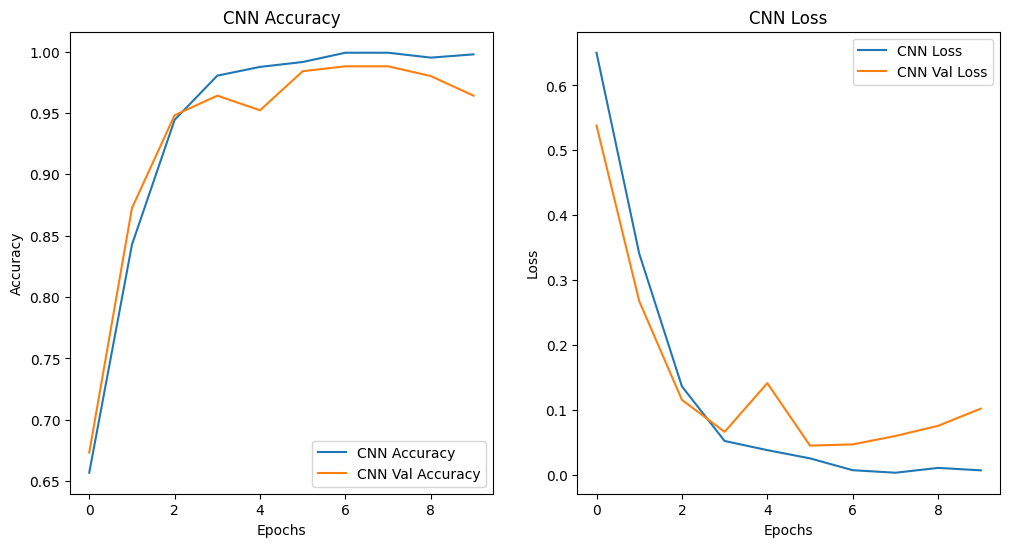

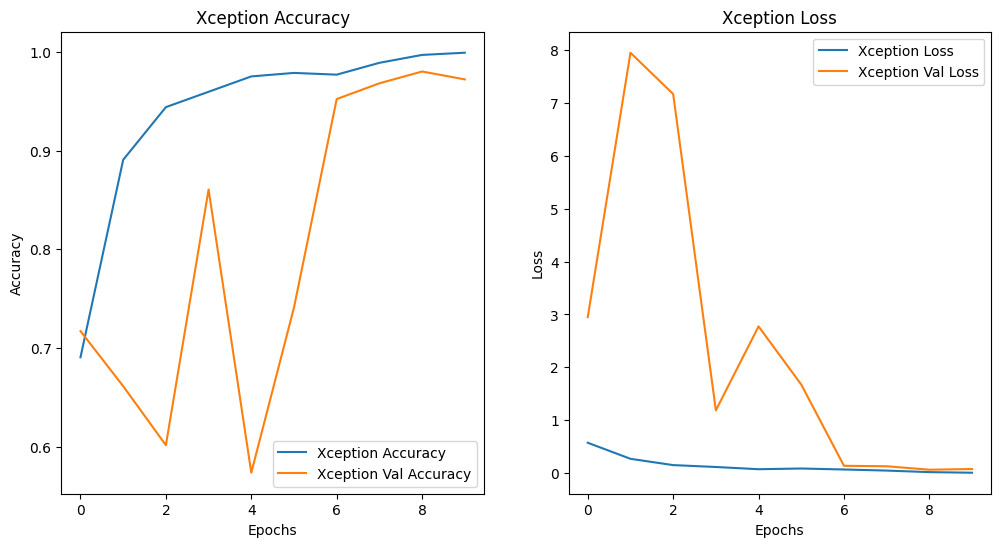

In [ ]:
# CNN Model 
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_s, y_test)
print("CNN Test Loss:", cnn_loss)
print("CNN Test Accuracy:", cnn_acc)

# Xception Model 
xception_loss, xception_acc = xception_model.evaluate(x_test_s, y_test)
print("Xception Test Loss:", xception_loss)
print("Xception Test Accuracy:", xception_acc)


plt.figure(figsize=(12, 6))

# CNN Accuracy vs Loss Graph
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Xception Accuracy vs Loss Graph
plt.figure(figsize=(12, 6))

# Xception Accuracy vs Loss Graph
plt.subplot(1, 2, 1)
plt.plot(xception_history.history['accuracy'], label='Xception Accuracy')
plt.plot(xception_history.history['val_accuracy'], label='Xception Val Accuracy')
plt.title('Xception Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(xception_history.history['loss'], label='Xception Loss')
plt.plot(xception_history.history['val_loss'], label='Xception Val Loss')
plt.title('Xception Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

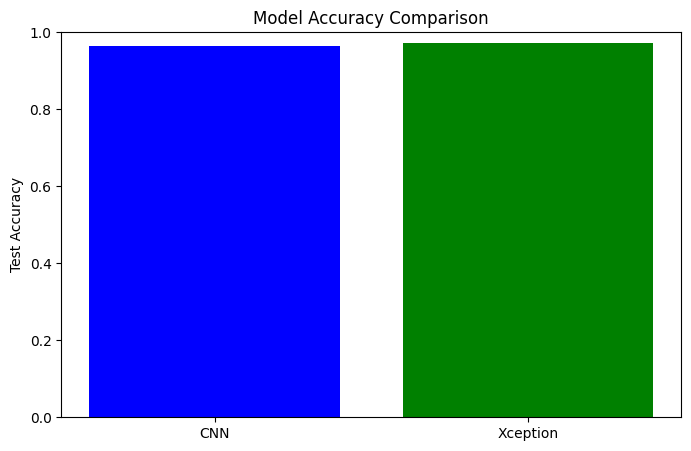

In [17]:
# Compare Test Accuracies
models = ['CNN', 'Xception']
accuracies = [cnn_acc, xception_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['Blue', 'green'])
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


In [18]:
from sklearn.metrics import classification_report

# Get model predictions
cnn_pred = (cnn_model.predict(x_test_s) > 0.5).astype("int32")
xception_pred = (xception_model.predict(x_test_s) > 0.5).astype("int32")

# Print Classification Reports
print("CNN Model Report:\n", classification_report(y_test, cnn_pred))
print("\nXception Model Report:\n", classification_report(y_test, xception_pred))


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step
CNN Model Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       161
           1       0.93      0.98      0.95        90

    accuracy                           0.96       251
   macro avg       0.96      0.97      0.96       251
weighted avg       0.97      0.96      0.96       251


Xception Model Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       161
           1       0.99      0.93      0.96        90

    accuracy                           0.97       251
   macro avg       0.98      0.96      0.97       251
weighted avg       0.97      0.97      0.97       251



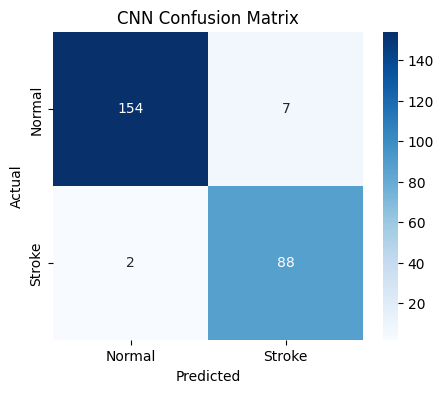

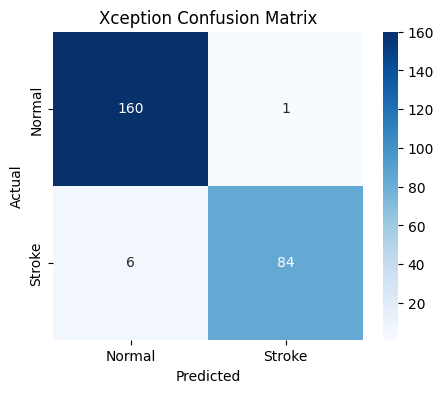

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Stroke"], yticklabels=["Normal", "Stroke"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

plot_confusion_matrix("CNN", y_test, cnn_pred)
plot_confusion_matrix("Xception", y_test, xception_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


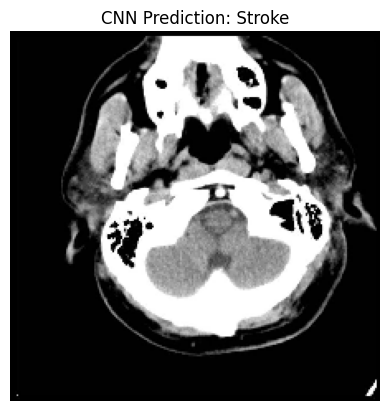

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


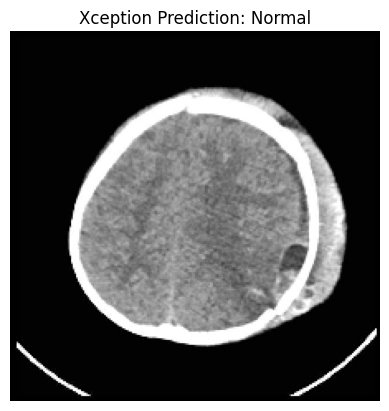

In [20]:
from tensorflow.keras.preprocessing import image

def predict_new_image(model, img_path, model_name):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    label = "Stroke" if prediction[0][0] > 0.5 else "Normal"

    plt.imshow(img)
    plt.title(f"{model_name} Prediction: {label}")
    plt.axis("off")
    plt.show()

# Test new image (replace 'test_image.jpg' with an actual image path)
predict_new_image(cnn_model, 'C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\69 (8).jpg', "CNN")
predict_new_image(xception_model, 'C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Normal\\50 (22).jpg', "Xception")


In [21]:
# Save CNN and Xception models
cnn_model.save("C:\Brain Stroke image dataset\Brain_Data_Organised\cnn_brain_stroke_model.h5")
xception_model.save("C:\Brain Stroke image dataset\Brain_Data_Organised\ xception_brain_stroke_model.h5")



<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:3: SyntaxWarning: invalid escape sequence '\B'
<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:3: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Nimiti\AppData\Local\Temp\ipykernel_1400\974037883.py:2: SyntaxWarning: invalid escape sequence '\B'
  cnn_model.save("C:\Brain Stroke image dataset\Brain_Data_Organised\cnn_brain_stroke_model.h5")
C:\Users\Nimiti\AppData\Local\Temp\ipykernel_1400\974037883.py:3: SyntaxWarning: invalid escape sequence '\B'
  xception_model.save("C:\Brain Stroke image dataset\Brain_Data_Organised\ xception_brain_stroke_model.h5")


In [22]:
from tensorflow.keras.models import load_model
cnn_loaded = load_model("C:\Brain Stroke image dataset\Brain_Data_Organised\cnn_brain_stroke_model.h5")
xception_loaded = load_model("C:\Brain Stroke image dataset\Brain_Data_Organised\ xception_brain_stroke_model.h5")


<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:3: SyntaxWarning: invalid escape sequence '\B'
<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:3: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Nimiti\AppData\Local\Temp\ipykernel_1400\68009576.py:2: SyntaxWarning: invalid escape sequence '\B'
  cnn_loaded = load_model("C:\Brain Stroke image dataset\Brain_Data_Organised\cnn_brain_stroke_model.h5")
C:\Users\Nimiti\AppData\Local\Temp\ipykernel_1400\68009576.py:3: SyntaxWarning: invalid escape sequence '\B'
  xception_loaded = load_model("C:\Brain Stroke image dataset\Brain_Data_Organised\ xception_brain_stroke_model.h5")


In [23]:
import pickle

# Save CNN history
with open("C:\Brain Stroke image dataset\cnn_history.pkl", "wb") as file:
    pickle.dump(cnn_history.history, file)

# Save Xception history
with open("C:\Brain Stroke image dataset\ xception_history.pkl", "wb") as file:
    pickle.dump(xception_history.history, file)


<>:4: SyntaxWarning: invalid escape sequence '\B'
<>:8: SyntaxWarning: invalid escape sequence '\B'
<>:4: SyntaxWarning: invalid escape sequence '\B'
<>:8: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Nimiti\AppData\Local\Temp\ipykernel_1400\2049705721.py:4: SyntaxWarning: invalid escape sequence '\B'
  with open("C:\Brain Stroke image dataset\cnn_history.pkl", "wb") as file:
C:\Users\Nimiti\AppData\Local\Temp\ipykernel_1400\2049705721.py:8: SyntaxWarning: invalid escape sequence '\B'
  with open("C:\Brain Stroke image dataset\ xception_history.pkl", "wb") as file:


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step


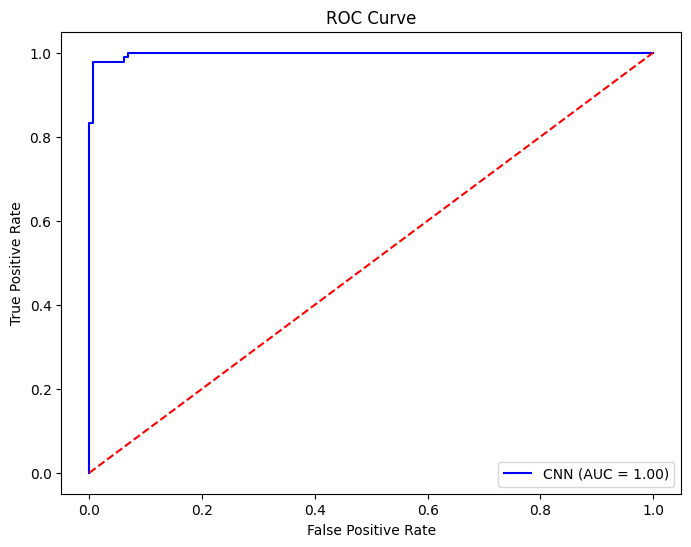

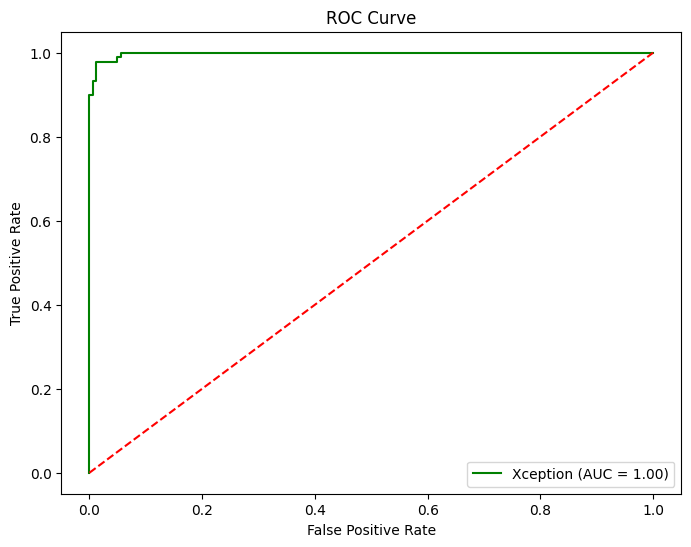

In [27]:
from sklearn.metrics import roc_curve, auc

# Get CNN model probabilities
cnn_probs = cnn_model.predict(x_test_s).ravel()
xception_probs = xception_model.predict(x_test_s).ravel()

# Compute ROC Curve
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_probs)
fpr_xception, tpr_xception, _ = roc_curve(y_test, xception_probs)

# Compute AUC Scores
auc_cnn = auc(fpr_cnn, tpr_cnn)
auc_xception = auc(fpr_xception, tpr_xception)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC = {auc_cnn:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xception, tpr_xception, label=f'Xception (AUC = {auc_xception:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get probabilities
cnn_probs = cnn_model.predict(x_test_s).ravel()
xception_probs = xception_model.predict(x_test_s).ravel()

# Compute Precision-Recall Curve
precision_cnn, recall_cnn, _ = precision_recall_curve(y_test, cnn_probs)
precision_xception, recall_xception, _ = precision_recall_curve(y_test, xception_probs)

# Compute Average Precision Score
ap_cnn = average_precision_score(y_test, cnn_probs)
ap_xception = average_precision_score(y_test, xception_probs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step


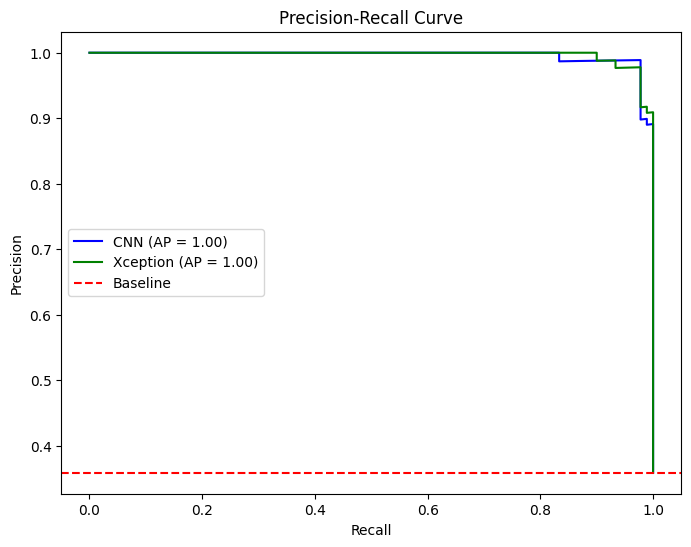

In [29]:
plt.figure(figsize=(8, 6))

# CNN PR Curve
plt.plot(recall_cnn, precision_cnn, label=f'CNN (AP = {ap_cnn:.2f})', color='blue')

# Xception PR Curve
plt.plot(recall_xception, precision_xception, label=f'Xception (AP = {ap_xception:.2f})', color='green')

# Baseline
plt.axhline(y=sum(y_test)/len(y_test), linestyle='--', color='red', label='Baseline')

# Labels and Title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


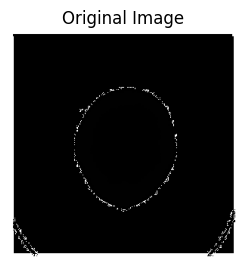

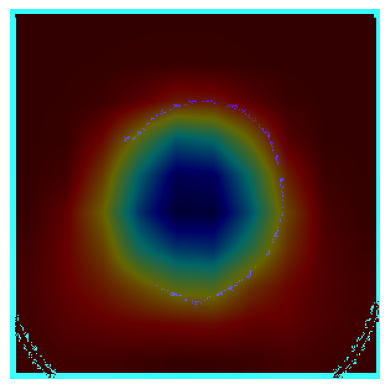

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# Load Pre-trained Model (Xception as an example)
model = Xception(weights='imagenet')  # Replace with your custom model if needed

# Prepare Image for Prediction
img_path = 'C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\58 (35).jpg'  # Replace with your image path
img = image.load_img(img_path, target_size=(299, 299))  # Resize for Xception
img_array = image.img_to_array(img)  # Convert image to array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = tf.keras.applications.xception.preprocess_input(img_array)  # Preprocess for Xception

# Select the Last Convolutional Layer
last_conv_layer = model.get_layer('block14_sepconv2_act')  # Change layer if necessary

# Correcting how grad_model is constructed
grad_model = Model(
    inputs=model.input,  # Input layer of the model
    outputs=[last_conv_layer.output, model.output]  # Last convolutional layer and the model's output
)


# Compute Gradients with GradientTape
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, np.argmax(predictions[0])]  # Get the loss for the predicted class


# Compute Grad-CAM
grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # Global average pooling
heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
heatmap = np.squeeze(heatmap)  # Remove extra dimensions

# Post-process the Heatmap
heatmap = np.maximum(heatmap, 0)  # Apply ReLU to keep only positive values
heatmap /= np.max(heatmap)  # Normalize to 0-1
heatmap = cv2.resize(heatmap, (299, 299))  # Resize to 299x299 for blending

# Convert image to RGB (if needed)
img_array_rgb = cv2.cvtColor(img_array[0].astype('uint8'), cv2.COLOR_BGR2RGB)

# Convert heatmap to RGB and blend with original image
heatmap = np.uint8(255 * heatmap)  # Convert heatmap to 0-255 range
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)  # Apply colormap to heatmap
superimposed_img = heatmap * 0.4 + img_array_rgb  # Blend the heatmap with the original image

# Plot original image
plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
plt.imshow(img_array_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

# Display the result
superimposed_img = np.uint8(superimposed_img)  # Ensure the image is in valid range
plt.imshow(superimposed_img)
plt.axis('off')
plt.show()


In [3]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten
from PIL import Image 


normal_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Normal"
stroke_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke"
normal_folder = os.listdir(normal_path)
stroke_folder = os.listdir(stroke_path)

data = []


for img_file in normal_folder:
    image = Image.open(normal_path + "/" + img_file)
    image = image.resize((224,224))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)
    
for img_file in stroke_folder:
    image = Image.open(stroke_path + "/" + img_file)
    image = image.resize((224,224))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)

normal_label = [0]*len(normal_folder)
stroke_label = [1]*len(stroke_folder)

Target_label = normal_label + stroke_label
x = np.array(data)
y = np.array(Target_label)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10, shuffle=True)
print(x_train.shape, x_test.shape)

# Normalization
x_train_s = x_train / 255
x_test_s = x_test / 255
# Load ResNet50 Model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Create ResNet Model
resnet_model = Model(inputs=base_model.input, outputs=predictions)
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
resnet_history = resnet_model.fit(x_train_s, y_train, batch_size=32, epochs=10, validation_data=(x_test_s, y_test))

# Evaluate Model
resnet_loss, resnet_acc = resnet_model.evaluate(x_test_s, y_test)
print("ResNet Test Accuracy:", resnet_acc)



(2250, 224, 224, 3) (251, 224, 224, 3)
Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 637s 8s/step - accuracy: 0.6097 - loss: 0.7214 - val_accuracy: 0.6255 - val_loss: 0.9752
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 592s 8s/step - accuracy: 0.7877 - loss: 0.4622 - val_accuracy: 0.6175 - val_loss: 1.9217
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 615s 9s/step - accuracy: 0.8446 - loss: 0.3462 - val_accuracy: 0.3825 - val_loss: 4.8298
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 586s 8s/step - accuracy: 0.9199 - loss: 0.1941 - val_accuracy: 0.3825 - val_loss: 2.3526
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 573s 8s/step - accuracy: 0.9249 - loss: 0.2059 - val_accuracy: 0.3825 - val_loss: 1.0189
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 586s 8s/step - accuracy: 0.8960 - loss: 0.3011 - val_accuracy: 0.3825 - val_loss: 16.2508
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 573s 8s/step - accuracy: 0.9312 - loss: 0.1740 - val_accuracy: 0.3825 - val_loss: 1.1459
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 565s 8s/step - accuracy: 0.9696 -

In [20]:
# Evaluate MobileNetV2
resnet_loss, resnet_acc = resnet_model.evaluate(x_test_s, y_test)
print("\nResnet Test Accuracy:", resnet_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.3794 - loss: 8.2652

Resnet Test Accuracy: 0.4063745141029358


In [23]:
from sklearn.metrics import classification_report

# Get model predictions
resnet_pred = (resnet_model.predict(x_test_s) > 0.5).astype("int32")


# Print Classification Reports
print("Resnet Model Report:\n", classification_report(y_test, resnet_pred))


8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step
Resnet Model Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       149
           1       0.41      1.00      0.58       102

    accuracy                           0.41       251
   macro avg       0.20      0.50      0.29       251
weighted avg       0.17      0.41      0.23       251



c:\Users\Nimiti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Nimiti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Nimiti\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step


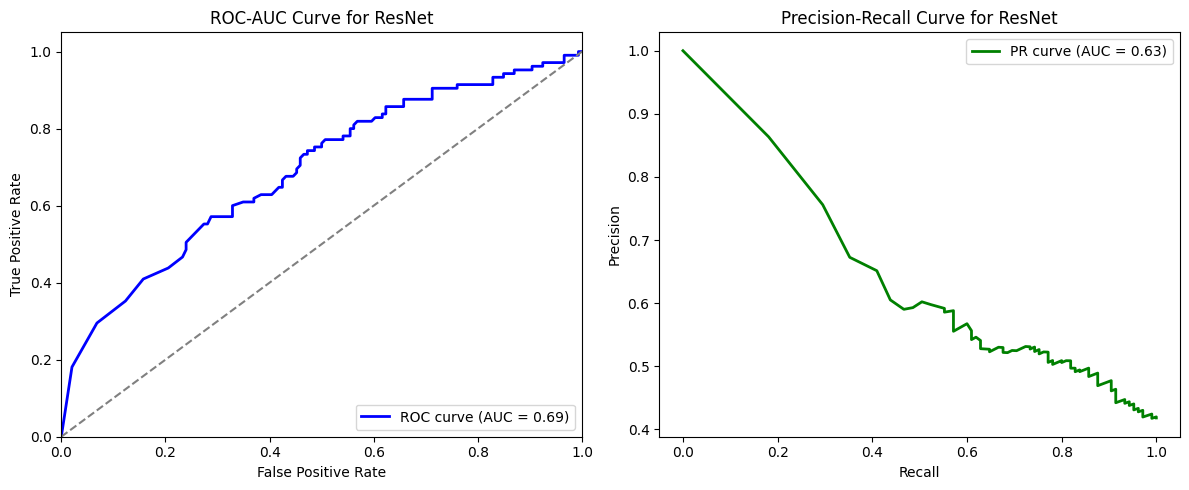

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Get predicted probabilities for ResNet
y_pred_prob = resnet_model.predict(x_test_s)  # Ensure X_test is preprocessed correctly

# Compute ROC curve and AUC score
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Compute Precision-Recall curve and AUC score
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

# Plot ROC-AUC Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve for ResNet')
plt.legend(loc='lower right')

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for ResNet')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


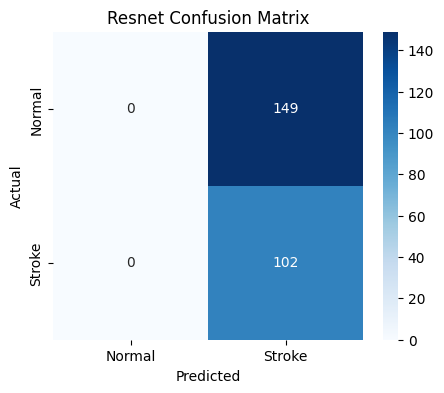

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Stroke"], yticklabels=["Normal", "Stroke"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

plot_confusion_matrix("Resnet", y_test, resnet_pred)



In [4]:
# Import Required Libraries
from tensorflow.keras.applications import MobileNetV2, InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten
from PIL import Image

# Define Paths
normal_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Normal"
stroke_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke"

# Load Image Data
data, labels = [], []

for img_file in os.listdir(normal_path):
    image = Image.open(os.path.join(normal_path, img_file))
    image = image.resize((224, 224)).convert('RGB')
    data.append(np.array(image))
    labels.append(0)  # Normal -> Label 0

for img_file in os.listdir(stroke_path):
    image = Image.open(os.path.join(stroke_path, img_file))
    image = image.resize((224, 224)).convert('RGB')
    data.append(np.array(image))
    labels.append(1)  # Stroke -> Label 1

# Convert to NumPy Arrays
x = np.array(data)
y = np.array(labels)

# Split Dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10, shuffle=True, random_state=42)

# Normalize Data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Define MobileNetV2 Model
base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(inputs=base_mobilenet.input, outputs=predictions)
mobilenet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define InceptionV3 Model
base_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_inception.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)

inception_model = Model(inputs=base_inception.input, outputs=predictions)
inception_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print Model Summaries
print("\nMobileNetV2 Model Summary:")
mobilenet_model.summary()
print("\nInceptionV3 Model Summary:")
inception_model.summary()

# Train MobileNetV2
mobilenet_history = mobilenet_model.fit(x_train, y_train, batch_size=32, epochs=10, validation_data=(x_test, y_test))

# Train InceptionV3
inception_history = inception_model.fit(x_train, y_train, batch_size=32, epochs=10, validation_data=(x_test, y_test))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step

MobileNetV2 Model Summary:


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,618,945 (9.99 MB)

 Trainable params: 2,584,833 (9.86 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,360,353 (85.30 MB)

 Trainable params: 22,325,921 (85.17 MB)

 Non-trainable params: 34,432 (134.50 KB)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 303s 4s/step - accuracy: 0.6653 - loss: 0.6185 - val_accuracy: 0.4622 - val_loss: 1.2572
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 262s 4s/step - accuracy: 0.8389 - loss: 0.3610 - val_accuracy: 0.7450 - val_loss: 1.0211
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 260s 4s/step - accuracy: 0.9212 - loss: 0.2179 - val_accuracy: 0.6693 - val_loss: 1.8918
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.9488 - loss: 0.1448 - val_accuracy: 0.6853 - val_loss: 1.7433
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 257s 4s/step - accuracy: 0.9711 - loss: 0.0838 - val_accuracy: 0.7331 - val_loss: 2.9048
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 260s 4s/step - accuracy: 0.9638 - loss: 0.1005 - val_accuracy: 0.7171 - val_loss: 2.8460
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 261s 4s/step - accuracy: 0.9749 - loss: 0.0745 - val_accuracy: 0.4183 - val_loss: 10.6237
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 256s 4s/step - accuracy: 0.9613 - loss: 0.1337 - val_accuracy: 0.4064 - 

In [5]:
# Evaluate MobileNetV2
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(x_test, y_test)
print("\nMobileNetV2 Test Accuracy:", mobilenet_acc)

# Evaluate InceptionV3
inception_loss, inception_acc = inception_model.evaluate(x_test, y_test)
print("\nInceptionV3 Test Accuracy:", inception_acc)


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 731ms/step - accuracy: 0.3893 - loss: 8.0671

MobileNetV2 Test Accuracy: 0.41035857796669006
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 747ms/step - accuracy: 0.6593 - loss: 15.7879

InceptionV3 Test Accuracy: 0.6374502182006836


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 734ms/step - accuracy: 0.3878 - loss: 9.5072
Mobilenet Test Loss: 9.025174140930176
Mobilenet Test Accuracy: 0.41434264183044434
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 746ms/step - accuracy: 0.6018 - loss: 42.8908
Inception Test Loss: 52.05075454711914
Inception Test Accuracy: 0.5737051963806152


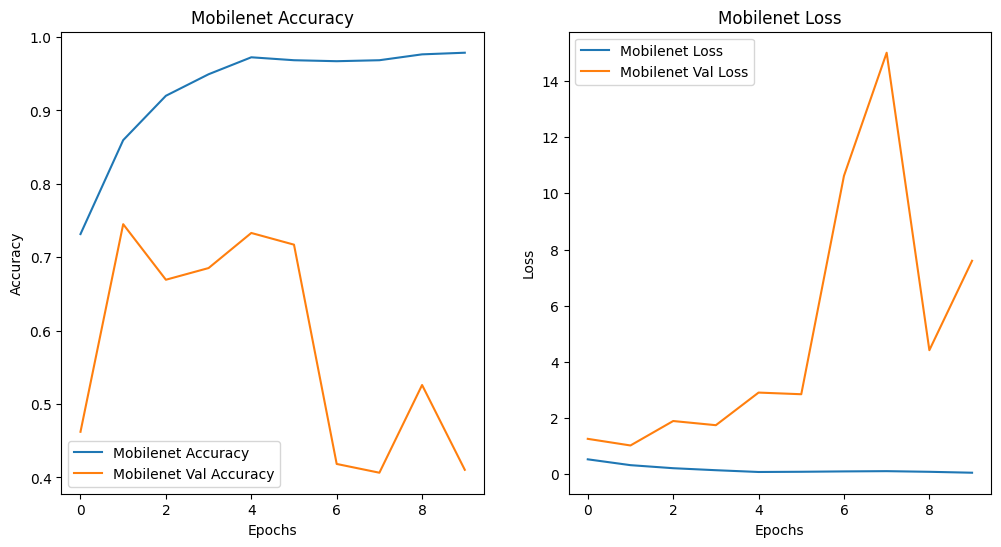

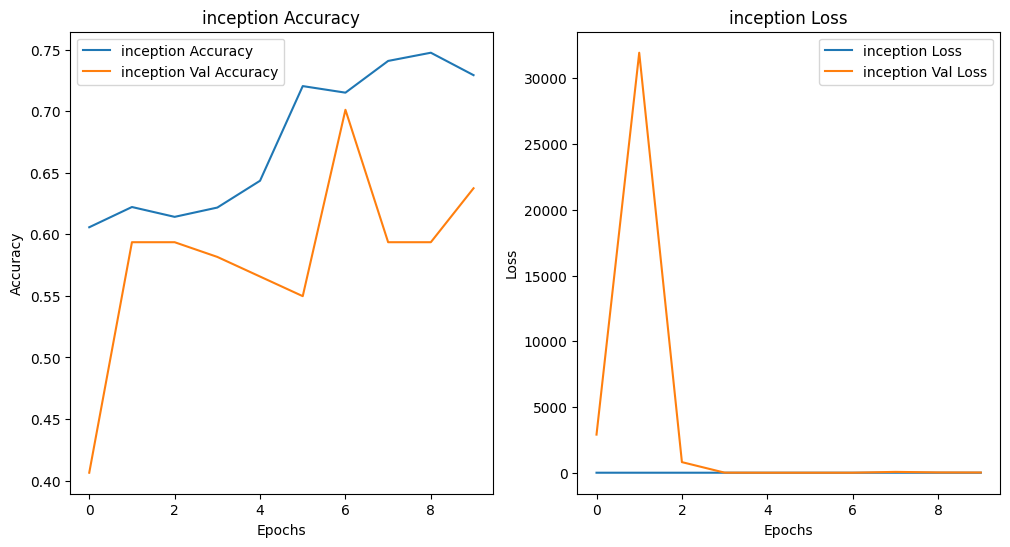

In [ ]:
# MobilnetV2 Model
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(x_test, y_test)
print("Mobilenet Test Loss:", mobilenet_loss)
print("Mobilenet Test Accuracy:", mobilenet_acc)

# Inceptionv3 Model 
inception_loss, inception_acc = inception_model.evaluate(x_test, y_test)
print("Inception Test Loss:", inception_loss)
print("Inception Test Accuracy:", inception_acc)

plt.figure(figsize=(12, 6))

# MobilenetV2 Accuracy vs loss graph
plt.subplot(1, 2, 1)
plt.plot(mobilenet_history.history['accuracy'], label='Mobilenet Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Mobilenet Val Accuracy')
plt.title('Mobilenet Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mobilenet_history.history['loss'], label='Mobilenet Loss')
plt.plot(mobilenet_history.history['val_loss'], label='Mobilenet Val Loss')
plt.title('Mobilenet Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# InceptionV3 Accuracy vs Loss graph
plt.figure(figsize=(12, 6))

# InceptionV3 Accuracy vs Loss Graph
plt.subplot(1, 2, 1)
plt.plot(inception_history.history['accuracy'], label='inception Accuracy')
plt.plot(inception_history.history['val_accuracy'], label='inception Val Accuracy')
plt.title('inception Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(inception_history.history['loss'], label='inception Loss')
plt.plot(inception_history.history['val_loss'], label='inception Val Loss')
plt.title('inception Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [9]:
# Classification Report
from sklearn.metrics import classification_report

mobilenet_pred = (mobilenet_model.predict(x_test) > 0.5).astype("int32")
inception_pred = (inception_model.predict(x_test) > 0.5).astype("int32")

print("\nMobileNetV2 Classification Report:\n", classification_report(y_test, mobilenet_pred))
print("\nInceptionV3 Classification Report:\n", classification_report(y_test, inception_pred))


8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 896ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step 

MobileNetV2 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.01      0.01       149
           1       0.41      1.00      0.58       102

    accuracy                           0.41       251
   macro avg       0.70      0.50      0.30       251
weighted avg       0.76      0.41      0.24       251


InceptionV3 Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.93      0.75       149
           1       0.68      0.21      0.32       102

    accuracy                           0.64       251
   macro avg       0.65      0.57      0.53       251
weighted avg       0.65      0.64      0.58       251



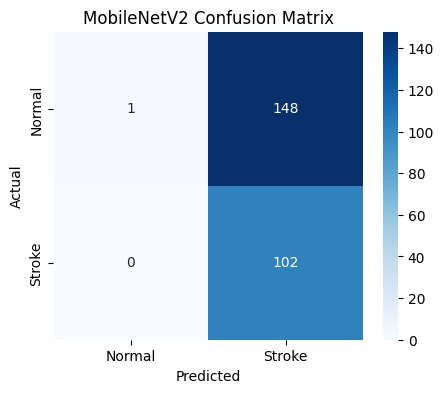

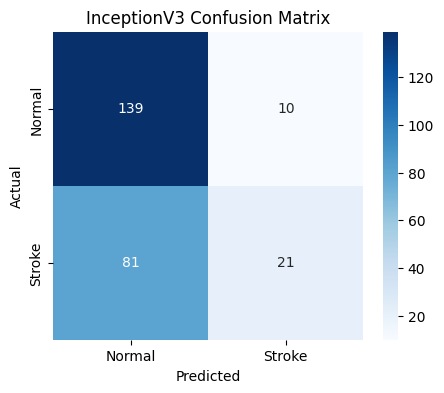

In [10]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Stroke"], yticklabels=["Normal", "Stroke"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

plot_confusion_matrix("MobileNetV2", y_test, mobilenet_pred)
plot_confusion_matrix("InceptionV3", y_test, inception_pred)



8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 767ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 775ms/step


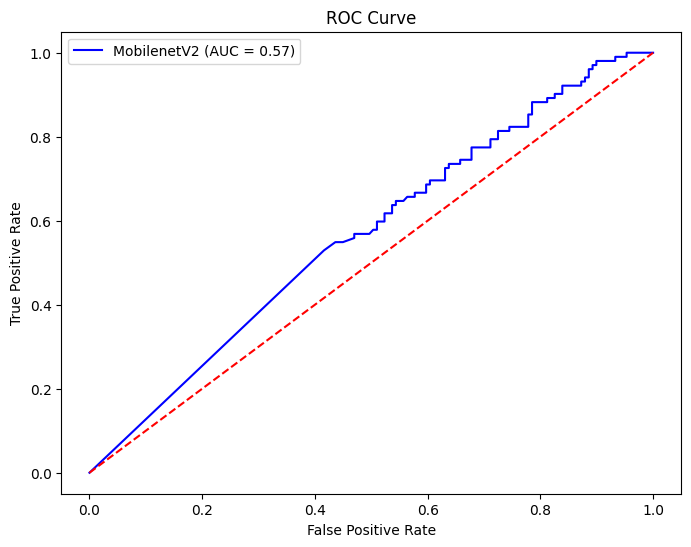

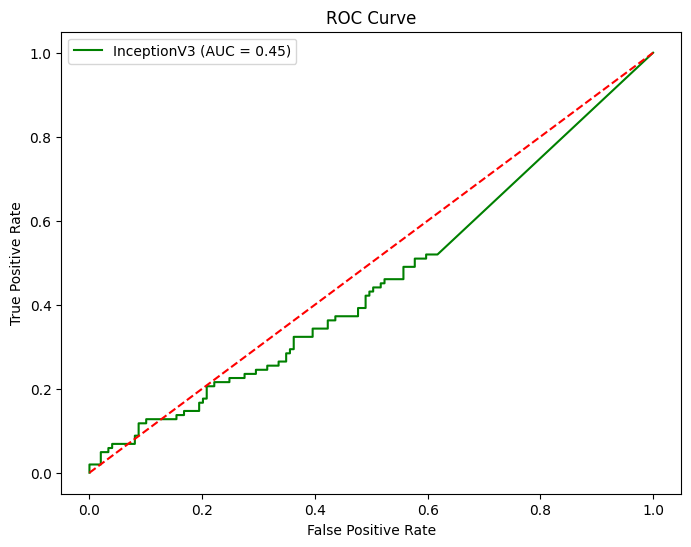

In [11]:
from sklearn.metrics import roc_curve, auc

# Get MobilenetV2 and InceptionV3 model probabilities
mobilenet_probs = mobilenet_model.predict(x_test_s).ravel()
inception_probs = inception_model.predict(x_test_s).ravel()

# Compute ROC Curve
fpr_mobilenet, tpr_mobilenet, _ = roc_curve(y_test, mobilenet_probs)
fpr_inception, tpr_inception, _ = roc_curve(y_test, inception_probs)

# Compute AUC Scores
auc_mobilenet = auc(fpr_mobilenet, tpr_mobilenet)
auc_inception = auc(fpr_inception, tpr_inception)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_mobilenet, tpr_mobilenet, label=f'MobilenetV2 (AUC = {auc_mobilenet:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_inception, tpr_inception, label=f'InceptionV3 (AUC = {auc_inception:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()



In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get probabilities
mobilenet_probs = mobilenet_model.predict(x_test_s).ravel()
inception_probs = inception_model.predict(x_test_s).ravel()

# Compute Precision-Recall Curve
precision_mobilenet, recall_mobilenet, _ = precision_recall_curve(y_test, mobilenet_probs)
precision_inception, recall_inception, _ = precision_recall_curve(y_test, inception_probs)

# Compute Average Precision Score
ap_mobilenet = average_precision_score(y_test, mobilenet_probs)
ap_inception = average_precision_score(y_test, inception_probs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 753ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 767ms/step


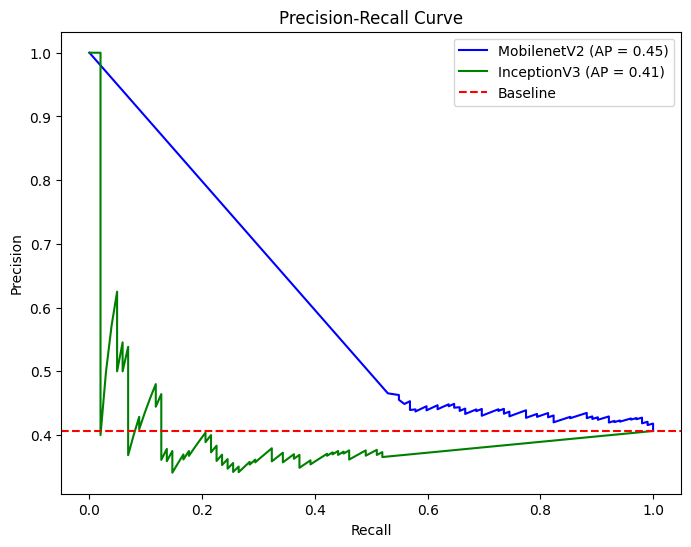

In [13]:
plt.figure(figsize=(8, 6))

# CNN PR Curve
plt.plot(recall_mobilenet, precision_mobilenet, label=f'MobilenetV2 (AP = {ap_mobilenet:.2f})', color='blue')

# Xception PR Curve
plt.plot(recall_inception, precision_inception, label=f'InceptionV3 (AP = {ap_inception:.2f})', color='green')

# Baseline
plt.axhline(y=sum(y_test)/len(y_test), linestyle='--', color='red', label='Baseline')

# Labels and Title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


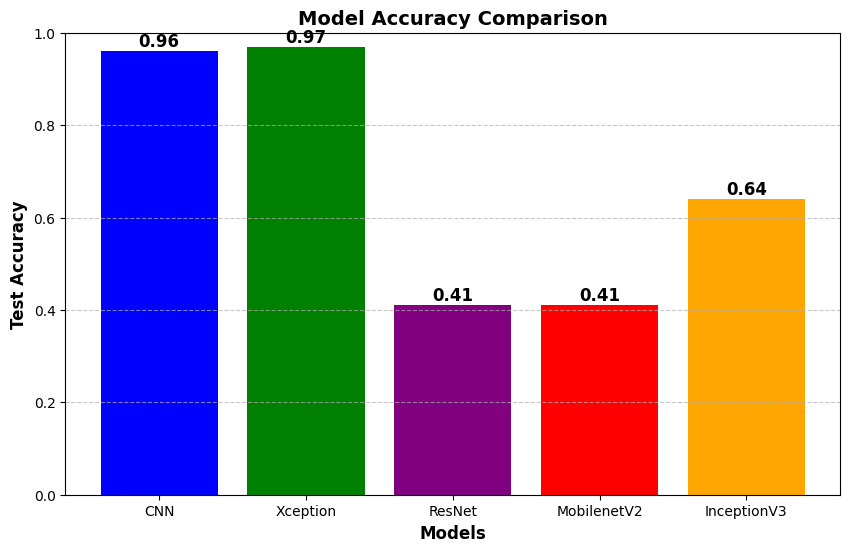

In [25]:
import matplotlib.pyplot as plt

# Accuracy values (replace these with actual values)
cnn_acc = 0.96       # Example accuracy for CNN
xception_acc = 0.97  # Example accuracy for Xception
resnet_acc = 0.41   # Example accuracy for ResNet
mobilenet_acc = 0.41  # Example accuracy for MobileNetV2
inception_acc = 0.64  # Example accuracy for InceptionV3

# Model names and their respective accuracies
models = ['CNN', 'Xception', 'ResNet', 'MobilenetV2', 'InceptionV3']
accuracies = [cnn_acc, xception_acc, resnet_acc, mobilenet_acc, inception_acc]

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['Blue', 'Green', 'Purple', 'Red', 'Orange'])

# Formatting the plot
plt.ylim(0, 1)
plt.ylabel("Test Accuracy", fontsize=12, fontweight='bold')
plt.xlabel("Models", fontsize=12, fontweight='bold')
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display accuracy values on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=12, fontweight='bold')

# Show the plot
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


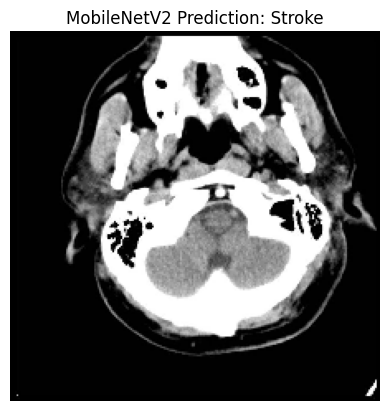

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


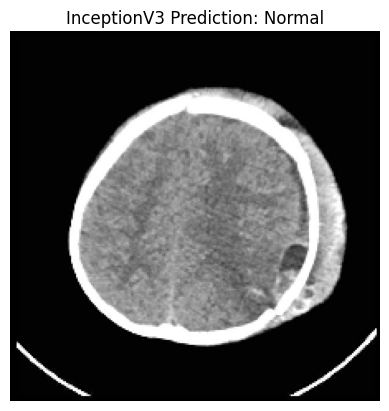

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


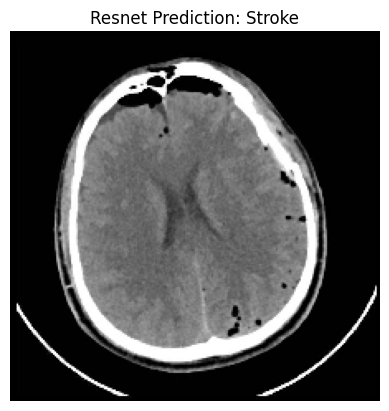

In [32]:
# Function for New Image Prediction
from tensorflow.keras.preprocessing import image

def predict_new_image(model, img_path, model_name):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    label = "Stroke" if prediction[0][0] > 0.5 else "Normal"

    plt.imshow(img)
    plt.title(f"{model_name} Prediction: {label}")
    plt.axis("off")
    plt.show()

# Test Predictions (Replace with actual image paths)
predict_new_image(mobilenet_model, 'C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\69 (8).jpg', "MobileNetV2")
predict_new_image(inception_model, 'C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Normal\\50 (22).jpg', "InceptionV3")
predict_new_image(resnet_model, 'C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Normal\\49 (2).jpg', "Resnet")


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten
from PIL import Image 


normal_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Normal"
stroke_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke"
normal_folder = os.listdir(normal_path)
stroke_folder = os.listdir(stroke_path)

data = []


for img_file in normal_folder:
    image = Image.open(normal_path + "/" + img_file)
    image = image.resize((224,224))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)
    
for img_file in stroke_folder:
    image = Image.open(stroke_path + "/" + img_file)
    image = image.resize((224,224))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image)

normal_label = [0]*len(normal_folder)
stroke_label = [1]*len(stroke_folder)

Target_label = normal_label + stroke_label
x = np.array(data)
y = np.array(Target_label)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10, shuffle=True)
print(x_train.shape, x_test.shape)

# Normalization
x_train_s = x_train / 255
x_test_s = x_test / 255

# Function to evaluate and print metrics clearly
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred = np.round(y_pred)  # Convert probabilities to 0 or 1

    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print results clearly
    print(f"\nModel: {model_name}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print("-" * 30)

evaluate_model(cnn_model, x_test_s, y_test, "CNN")
evaluate_model(xception_model, x_test_s, y_test, "Xception")
evaluate_model(resnet_model, x_test_s, y_test, "ResNet")
evaluate_model(mobilenet_model, x_test_s, y_test, "MobileNetV2")
evaluate_model(inception_model, x_test_s, y_test, "InceptionV3")


(2250, 224, 224, 3) (251, 224, 224, 3)
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step

Model: ResNet
Accuracy  : 0.4183
Precision : 0.4183
Recall    : 1.0000
F1-Score  : 0.5899
------------------------------
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 831ms/step

Model: MobileNetV2
Accuracy  : 0.4183
Precision : 0.4183
Recall    : 1.0000
F1-Score  : 0.5899
------------------------------
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 881ms/step

Model: InceptionV3
Accuracy  : 0.6574
Precision : 0.8519
Recall    : 0.2190
F1-Score  : 0.3485
------------------------------


In [42]:
import pandas as pd
from tabulate import tabulate

# Define model names and metrics
models = ["CNN", "Xception", "ResNet", "MobileNetV2", "InceptionV3"]
accuracy = [0.96, 0.97, 0.4183, 0.4183, 0.6574]
precision = [0.95, 0.96, 0.4183, 0.4183, 0.8519]
recall = [0.97, 0.98, 1.0000, 1.0000, 0.2190]
f1_score = [0.96, 0.97, 0.5899, 0.5899, 0.3485]

# Create a DataFrame
df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1_score
})

# Display the table
print(tabulate(df, headers='keys', tablefmt='grid'))


+----+-------------+------------+-------------+----------+------------+
|    | Model       |   Accuracy |   Precision |   Recall |   F1-Score |
+====+=============+============+=============+==========+============+
|  0 | CNN         |     0.96   |      0.95   |    0.97  |     0.96   |
+----+-------------+------------+-------------+----------+------------+
|  1 | Xception    |     0.97   |      0.96   |    0.98  |     0.97   |
+----+-------------+------------+-------------+----------+------------+
|  2 | ResNet      |     0.4183 |      0.4183 |    1     |     0.5899 |
+----+-------------+------------+-------------+----------+------------+
|  3 | MobileNetV2 |     0.4183 |      0.4183 |    1     |     0.5899 |
+----+-------------+------------+-------------+----------+------------+
|  4 | InceptionV3 |     0.6574 |      0.8519 |    0.219 |     0.3485 |
+----+-------------+------------+-------------+----------+------------+


C:\Users\Nimiti\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


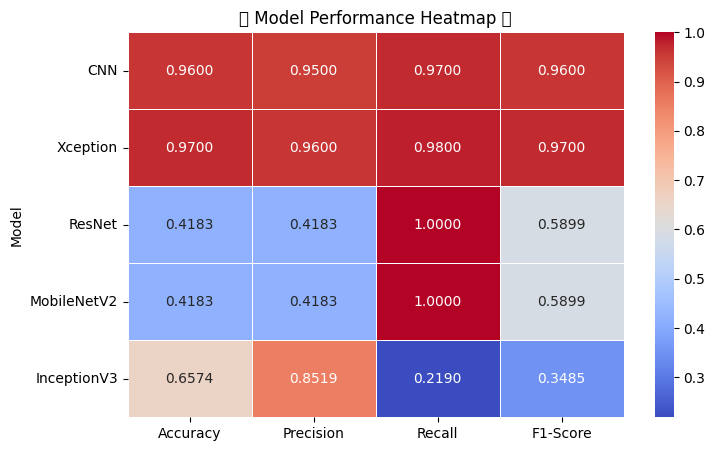

C:\Users\Nimiti\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


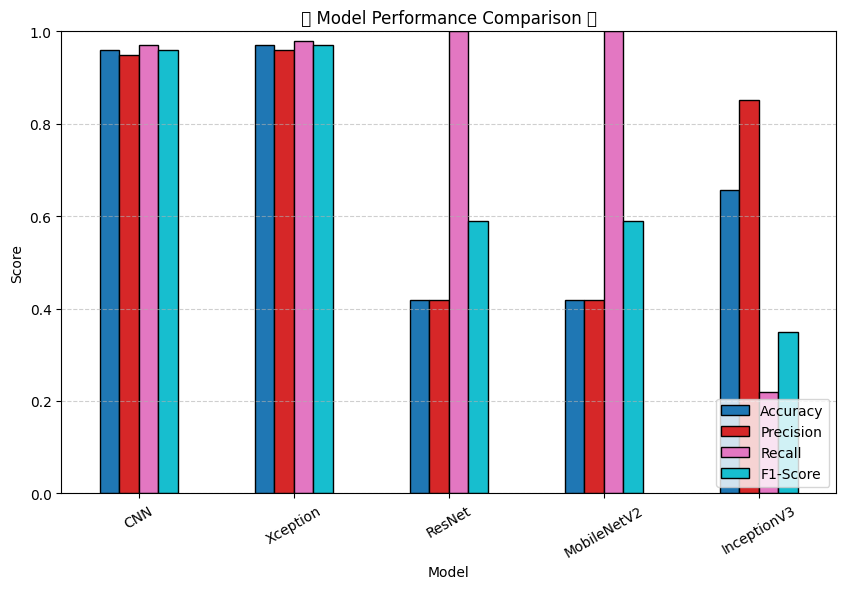

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define model names and metrics
models = ["CNN", "Xception", "ResNet", "MobileNetV2", "InceptionV3"]
accuracy = [0.96, 0.97, 0.4183, 0.4183, 0.6574]
precision = [0.95, 0.96, 0.4183, 0.4183, 0.8519]
recall = [0.97, 0.98, 1.0000, 1.0000, 0.2190]
f1_score = [0.96, 0.97, 0.5899, 0.5899, 0.3485]

# Create a DataFrame
df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1_score
})

# Set model names as index
df.set_index("Model", inplace=True)

# Plot Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df, annot=True, cmap="coolwarm", fmt=".4f", linewidths=0.5)
plt.title("🔥 Model Performance Heatmap 🔥")
plt.show()

# Bar Chart for Better Visualization
df.plot(kind="bar", figsize=(10, 6), colormap="tab10", edgecolor='black')
plt.title(" 📊 Model Performance Comparison 📊 ")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)  # Since all values are between 0 and 1
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


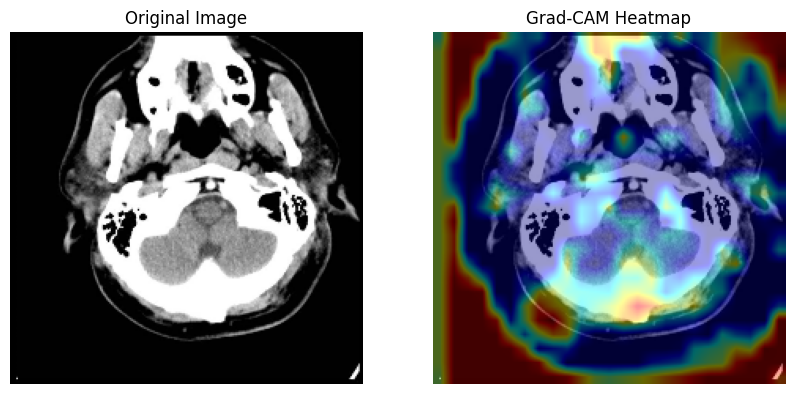

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def grad_cam(model, img_path, layer_name):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Define Grad-CAM model
    grad_model = tf.keras.models.Model(
        inputs=model.input, 
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        stroke_class_index = 1  # Adjust based on dataset class index
        stroke_class_index = 0  # For binary classification
        loss = predictions if predictions.shape[-1] == 1 else predictions[:, stroke_class_index]


    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Apply Grad-CAM heatmap
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX)  # ✅ Normalization fix
    heatmap = cv2.applyColorMap(np.uint8(heatmap), cv2.COLORMAP_JET)

    # Load and resize original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    # Overlay heatmap with increased visibility
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # Display images
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    ax[1].set_title("Grad-CAM Heatmap")
    ax[1].axis("off")

    plt.show()

# Run Grad-CAM for InceptionV3 
grad_cam(inception_model, 'C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\69 (8).jpg', 'activation_8')


Grad-CAM output saved as 'gradcam_output.png'


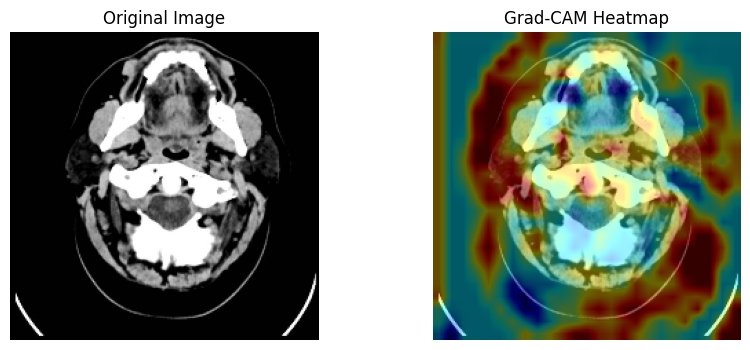

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

def grad_cam(model, img_path, layer_name):
    # Load and preprocess the image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize

    # Ensure single output tensor
    model_output = model.output if isinstance(model.output, tf.Tensor) else model.output[0]

    # Define Grad-CAM model
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model_output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = np.argmax(predictions[0])  # Get predicted class index
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Generate Heatmap
    conv_outputs = conv_outputs[0]
    heatmap = np.dot(conv_outputs, pooled_grads.numpy())
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    # Load Original Image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply heatmap to image
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # Display Results
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")


# Load the InceptionV3 model and recompile it
inception_model = tf.keras.models.load_model("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\inception_brain_stroke_model.h5")
inception_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])  # Fix missing compile issue

# Run Grad-CAM
grad_cam(inception_model, "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\58 (19).jpg", "activation_8")


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


  1%|          | 10/1000 [00:01<02:34,  6.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


  2%|▏         | 20/1000 [00:01<01:19, 12.33it/s]

...

 98%|█████████▊| 980/1000 [00:33<00:00, 31.31it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step


 99%|█████████▉| 990/1000 [00:33<00:00, 30.28it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


100%|██████████| 1000/1000 [00:33<00:00, 29.60it/s]


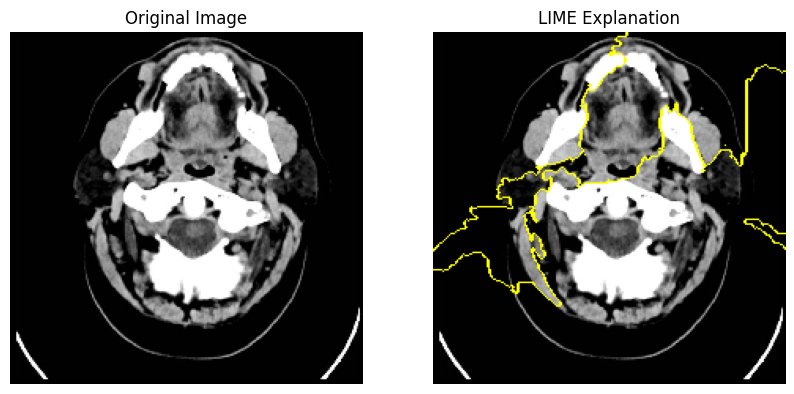

In [4]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Load the trained model
model = tf.keras.models.load_model("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\inception_brain_stroke_model.h5")

# Function to preprocess image
def preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize
    return np.expand_dims(img_array, axis=0)

# Prediction function for LIME
def model_predict(images):
    images = np.array(images)
    return model.predict(images)

# LIME explanation function
def explain_lime(image_path):
    img = preprocess_image(image_path)[0]  # Load and preprocess image

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(img, model_predict, top_labels=1, hide_color=0, num_samples=1000)

    # Get mask and superpixels for visualization
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)

    # Plot the original image and LIME explanation
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(mark_boundaries(temp, mask, color=(1, 1, 0)))  # Yellow boundaries for explanations
    ax[1].set_title("LIME Explanation")
    ax[1].axis("off")

    plt.show()

# Run LIME on a sample brain CT scan
explain_lime("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\58 (19).jpg")


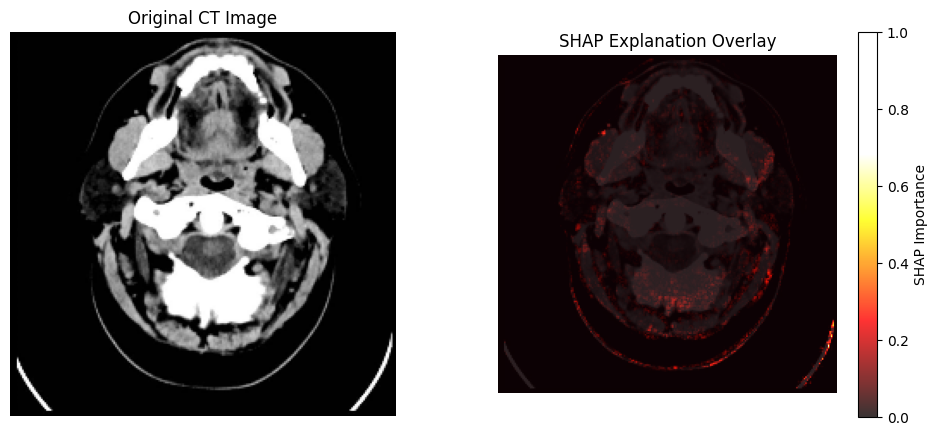

In [ ]:
import shap
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load trained CNN model
model = tf.keras.models.load_model("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\ xception_brain_stroke_model.h5")

# Function to preprocess the image
def preprocess_image(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read in grayscale
    img = cv2.resize(img, target_size)  # Resize
    img = img / 255.0  # Normalize
    img = np.expand_dims(img, axis=-1)  # Add channel dimension (224, 224, 1)
    img = np.repeat(img, 3, axis=-1)  # Convert to 3-channel RGB (224, 224, 3)
    img = np.expand_dims(img, axis=0)  # Add batch dimension (1, 224, 224, 3)
    return img

# Load and preprocess the input image
image_path = "C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\58 (19).jpg"
input_image = preprocess_image(image_path)

# Select a few background images for SHAP
background_images = np.vstack([
    preprocess_image("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\58 (1).jpg"),
    preprocess_image("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\58 (2).jpg"),
    preprocess_image("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\Stroke\\58 (3).jpg")
])

# Use Gradient SHAP
explainer = shap.GradientExplainer(model, background_images)
shap_values = explainer.shap_values(input_image)[0]  # Take first class output

# Apply absolute values to enhance contrast
shap_values = np.abs(shap_values)

# Normalize SHAP values for better visualization
shap_values = (shap_values - shap_values.min()) / (shap_values.max() - shap_values.min())

# Reshape SHAP values to remove extra dimensions
shap_values = np.squeeze(shap_values)  # Removes batch/channel dimensions

# Ensure it's still a 2D image
if len(shap_values.shape) > 2:
    shap_values = shap_values[:, :, 0]  # Take only the first channel if needed

# Convert SHAP heatmap to color using JET colormap
shap_colormap = cv2.applyColorMap((shap_values * 255).astype(np.uint8), cv2.COLORMAP_TURBO)

# Convert original grayscale image to 3-channel for overlay
original_ct_image = np.squeeze(input_image[0])  # Remove batch dimension
original_ct_image = (original_ct_image * 255).astype(np.uint8)  # Convert to uint8
# Ensure correct number of channels before conversion
if len(original_ct_image.shape) == 2 or original_ct_image.shape[-1] == 1:
    original_ct_image_colored = cv2.cvtColor(original_ct_image, cv2.COLOR_GRAY2BGR)
else:
    original_ct_image_colored = original_ct_image  # Already 3-channel, no need to convert

# Resize SHAP colormap to match the original image
shap_colormap = cv2.resize(shap_colormap, (original_ct_image.shape[1], original_ct_image.shape[0]))

# Blend the original CT image with the SHAP heatmap using weighted overlay
overlay = cv2.addWeighted(original_ct_image_colored, 0.6, shap_colormap, 0.4, 0)

# Plot results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Original Image
ax[0].imshow(original_ct_image, cmap='gray')
ax[0].set_title("Original CT Image")
ax[0].axis("off")

# SHAP Overlay Image
ax[1].imshow(overlay)
ax[1].set_title("SHAP Explanation Overlay")
ax[1].axis("off")

# Colorbar for SHAP values
cbar = plt.colorbar(ax[1].imshow(shap_values, cmap='hot', alpha=0.8), ax=ax[1])
cbar.set_label("SHAP Importance")
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.show()

In [92]:
mobilenet_model.save("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\mobilenet_brain_stroke_model.h5")
inception_model.save("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\inception_brain_stroke_model.h5")
resnet_model.save("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\resnet_brain_stroke_model.h5")
print("\nModels Saved Successfully!")


Models Saved Successfully!
